In [20]:
import pandas as pd

email_data = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/FYP PART 2/Priority Modeling/priority_subset_300.csv')

In [21]:
email_data.columns

Index(['From', 'To', 'Subject', 'Message', 'Day', 'Date & Time',
       'Cleaned_Subject', 'Cleaned_Message', 'Combined_Text', 'Subject_LLM',
       'Message_LLM', 'Email_Priority', 'urgency_flag', 'risk_flag',
       'urgency_and_risk', 'num_action_verbs', 'num_uppercase_words_subject',
       'subject_len', 'has_question'],
      dtype='object')

In [22]:
urgency_keywords = r'\b(asap|urgent|immediately|by \d{1,2}(am|pm)?|eod|cob|execs?|flagged|critical|today|escalate|priority|non[-\s]?compliance)\b'
email_data['urgency_flag'] = email_data['Combined_Text'].str.contains(urgency_keywords, case=False).astype(int)
risk_keywords = r'\b(flagged|compliance|audit|investigation|escalate|consequences|penalty|violation|breach|deadline|urgent review)\b'
email_data['risk_flag'] = email_data['Combined_Text'].str.contains(risk_keywords, case=False).astype(int)

C:\Users\User\AppData\Local\Temp\ipykernel_26360\9832084.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  email_data['urgency_flag'] = email_data['Combined_Text'].str.contains(urgency_keywords, case=False).astype(int)
C:\Users\User\AppData\Local\Temp\ipykernel_26360\9832084.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  email_data['risk_flag'] = email_data['Combined_Text'].str.contains(risk_keywords, case=False).astype(int)


In [ ]:
email_data

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

structured_features = [
    'urgency_flag', 'risk_flag',
       'urgency_and_risk', 'num_action_verbs', 'num_uppercase_words_subject',
       'subject_len', 'has_question'
]

text_feature = 'Combined_Text'
target_column = 'Email_Priority'

X = email_data[structured_features + [text_feature]]
y = email_data[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

In [6]:
tfidf = TfidfVectorizer(
    max_features=1000,  
    ngram_range=(1, 3),
    stop_words='english',
    lowercase=True
)

preprocessor = ColumnTransformer(
    transformers=[
        ('text', tfidf, text_feature),
        ('scale', StandardScaler(), structured_features)
    ]
)

# --- Step 5: Create the final preprocessed X ---
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

Random Forest Model
✅ Accuracy: 0.9666666666666667
📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        20
           1       0.91      1.00      0.95        20
           2       1.00      1.00      1.00        20

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



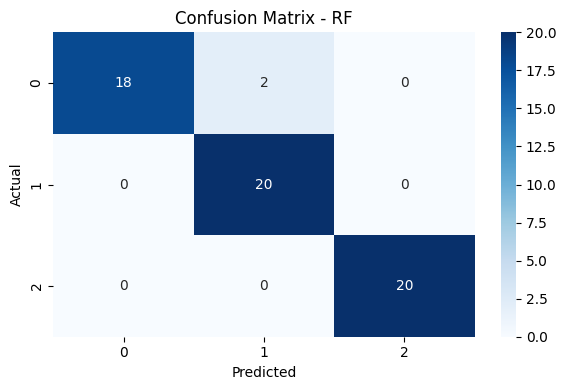

✅ Model saved successfully.


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_transformed, y_train)

# Step 2: Predict on the test set
y_pred = rf_model.predict(X_test_transformed)

print("Random Forest Model")
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                           index=rf_model.classes_,
                           columns=rf_model.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - RF")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("✅ Model saved successfully.")

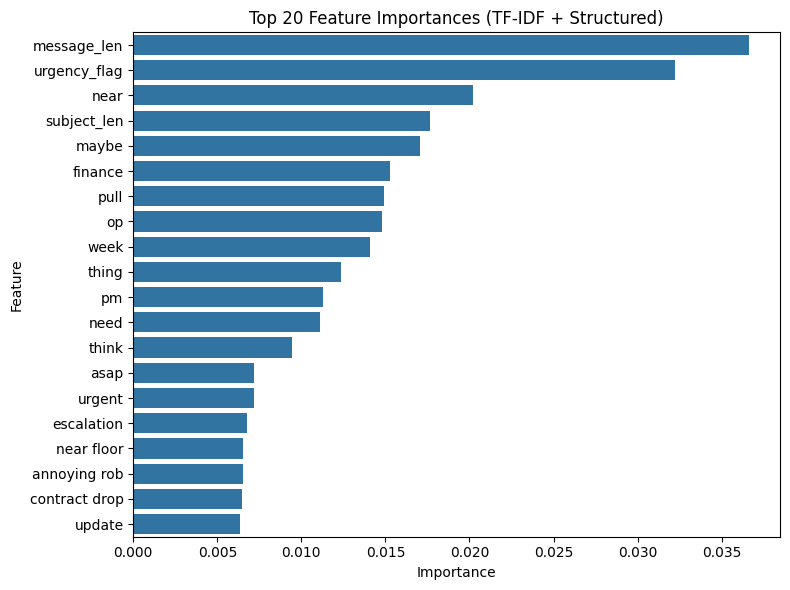

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Get TF-IDF feature names using the correct transformer name: 'text'
tfidf_feature_names = preprocessor.named_transformers_['text'].get_feature_names_out()

# Step 2: Combine TF-IDF feature names with structured ones
full_feature_names = list(tfidf_feature_names) + structured_features

# Step 3: Create DataFrame of feature importances
importance_df = pd.DataFrame({
    'Feature': full_feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Step 4: Plot top 20 features
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title("Top 20 Feature Importances (TF-IDF + Structured)")
plt.tight_layout()
plt.show()

In [ ]:
email_data